In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import duckdb
duckdb.execute("SET enable_progress_bar = false") #disables the bars that show run progress
import matplotlib.pyplot as plt

#baseline stuff
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#trees and boosting
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



In [3]:
from wind_diagnostics import plot_wind_diagnostics, plot_uv_agreement

from beach_geomorphology import get_geomorphology_df
beach_geo_df = get_geomorphology_df()


In [4]:
#loading all the data
load_prepared_datapath = "data/prepared_data/"
#precipitation
beach_coc_precip_df = pd.read_parquet(load_prepared_datapath + "COC_precip.parquet")
usgs_precip_df = pd.read_parquet(load_prepared_datapath + "usgs_precip.parquet")
#bacteria readings
readings_df = pd.read_parquet(load_prepared_datapath + "dna_readings.parquet")
#wind
beach_coc_wind_df = pd.read_parquet(load_prepared_datapath + "COC_wind.parquet")
chii2_wind_df = pd.read_parquet(load_prepared_datapath + "chii2_noaa.parquet")

In [5]:
# ─── Beach geomorphology (Mattheus et al. 2022a) ────────────────────────
from beach_geomorphology import get_geomorphology_df

beach_geo_df = get_geomorphology_df()

# Only model beaches that have Mattheus data
MATTHEUS_BEACHES = beach_geo_df[beach_geo_df["mattheus_id"].notna()].index.tolist()
print(f"Beaches with Mattheus geomorphology ({len(MATTHEUS_BEACHES)}):")
print(MATTHEUS_BEACHES)
print()

# Quick look at the key columns we'll use for wind features
print(beach_geo_df.loc[MATTHEUS_BEACHES, 
    ["lake_interface_az_deg", "facing_az_deg", 
     "downstream_groin_length_m", "lake_interface_length_m", "shape_index"]
])

Beaches with Mattheus geomorphology (13):
['leone', 'osterman', 'foster', 'montrose', 'north_avenue', 'oak_street', 'ohio_street', 'margaret_t_burroughs_31st', 'oakwood', '57th_street', '63rd_street', 'south_shore', 'rainbow']

                           lake_interface_az_deg  facing_az_deg  \
Beach                                                             
leone                                      138.0           48.0   
osterman                                   142.0           52.0   
foster                                     165.0           75.0   
montrose                                   133.0           43.0   
north_avenue                               151.0           61.0   
oak_street                                 147.0           57.0   
ohio_street                                238.0          148.0   
margaret_t_burroughs_31st                  110.0           20.0   
oakwood                                    138.0           48.0   
57th_street                        

In [6]:
#figures for wind data

# chii2_wind_df.set_index('timestamp_central').resample('D').size().plot(figsize=(14,3))
# plt.title('CHII2 records per day')
# plt.axhline(144, color='r', linestyle='--', label='expected (10-min × 24h)')
# plt.legend()
# fig1 = plot_wind_diagnostics(beach_coc_wind_df, chii2_wind_df)
# plt.show()
# fig2 = plot_uv_agreement(beach_coc_wind_df, chii2_wind_df)
# plt.show()

In [7]:
def check_timestamps(df, ts_col, name):
    """Quick health check on a timestamp column before using it."""
    n_total = len(df)
    n_null  = df[ts_col].isna().sum()
    
    print(f"\n{name}:")
    print(f"  Total rows:       {n_total:,}")
    print(f"  Null/NaT rows:    {n_null:,} ({n_null/n_total:.1%})")
    print(f"  Min timestamp:    {df[ts_col].min()}")
    print(f"  Max timestamp:    {df[ts_col].max()}")
    print(f"  Dtype:            {df[ts_col].dtype}")
    
    # tz-awareness check
    tz = getattr(df[ts_col].dt, 'tz', None)
    print(f"  Timezone:         {tz}")
# Step 0: Standardize all timestamps to tz-aware Central
# beach_coc_precip_df = standardize_to_central(beach_coc_precip_df, "timestamp_central")
# usgs_precip_df      = standardize_to_central(usgs_precip_df,      "timestamp_central")
# readings_df         = standardize_to_central(readings_df,         "DNA Sample Timestamp")

In [8]:
# Step 0.5: Check what you've got
check_timestamps(beach_coc_precip_df, "timestamp_central", "COC precip")
check_timestamps(usgs_precip_df,      "timestamp_central",     "USGS precip")
check_timestamps(readings_df,         "timestamp_central",  "DNA readings")
check_timestamps(beach_coc_wind_df,         "timestamp_central",  "coc wind")
check_timestamps(chii2_wind_df,         "timestamp_central",  "chii2 wind")


COC precip:
  Total rows:       202,698
  Null/NaT rows:    15 (0.0%)
  Min timestamp:    2015-04-25 09:00:00-05:00
  Max timestamp:    2026-04-23 11:00:00-05:00
  Dtype:            datetime64[us, America/Chicago]
  Timezone:         America/Chicago

USGS precip:
  Total rows:       1,825,937
  Null/NaT rows:    0 (0.0%)
  Min timestamp:    2021-04-30 19:00:00-05:00
  Max timestamp:    2025-09-29 19:00:00-05:00
  Dtype:            datetime64[us, America/Chicago]
  Timezone:         America/Chicago

DNA readings:
  Total rows:       12,241
  Null/NaT rows:    0 (0.0%)
  Min timestamp:    2015-05-26 00:00:00-05:00
  Max timestamp:    2025-09-01 12:04:00-05:00
  Dtype:            datetime64[ns, America/Chicago]
  Timezone:         America/Chicago

coc wind:
  Total rows:       92,706
  Null/NaT rows:    0 (0.0%)
  Min timestamp:    2021-05-17 15:00:00-05:00
  Max timestamp:    2026-04-23 11:00:00-05:00
  Dtype:            datetime64[us, America/Chicago]
  Timezone:         America/Chicag

Recipe is what I use to assemble data in a modular way in order to do feature engineering

In [9]:

# ─── Recipe config ──────────────────────────────────────────────────────
RECIPE = {
    "target_beach": "montrose",
    "min_year": 2021,

    "features": {
        "precip": {
            "enabled": True,
            "sources": [
                {"df_name": "beach_coc_precip_df",
                 "ts_col": "timestamp_central",
                 "value_col": "coc_mmprecip_sum1h",
                 "station_col": "station_name",
                 "label": "coc",
                 "bucket_minutes": 60,
                 "stations": ['foster', 'oak_street', '63rd_street']},
                {"df_name": "usgs_precip_df",
                 "ts_col": "timestamp_central",
                 "value_col": "usgs_mmprecip_sum5m",
                 "station_col": "station_name",
                 "label": "usgs",
                 "bucket_minutes": 5,
                 "stations": ['south_shore', 'hamilton_park_at_chicago',
                              'ping_tom_park_at_chicago', 'oakton_college_at_skokie',
                              'winnetka_golf_club_at_winnetka', 'cicero',
                              'north_austin', 'lake_view']},
            ],
            "sum_windows_hours": [6, 24, 48, 72],
            "max_windows_hours": [6],
        },

        "wind": {
            "enabled": True,
            "use_geo_features": True,
            "df_name": "chii2_wind_df",
            "windows_hours": [6, 12, 24],
            "tolerance_deg": 20,
            "min_coverage": 0.5,
        },

        "distance": {"enabled": False},
        "temp":     {"enabled": False},
        "sewer":    {"enabled": False},
    },
}

dataframes = {
    "beach_coc_precip_df": beach_coc_precip_df,
    "usgs_precip_df":      usgs_precip_df,
    "chii2_wind_df":       chii2_wind_df,
}


In [10]:
def get_target_readings(readings, target_beach, min_year):
    #take the beach name
    sifted_readings = duckdb.query("""
                                    SELECT
                                   Beach,
                                   reading,
                                   timestamp_central AS sample_ts
                                   FROM readings
                                   WHERE Beach = ? AND year >= ?
                                   ORDER BY sample_ts
                                    """, params = [target_beach,min_year]).df()
    return sifted_readings

In [11]:
def bucket_precip_per_station(precip_df, ts_col, value_col, station_col, bucket_minutes, stations): #snap precip to a regular grid, collapsing messy multistation data to be just a regular grid
    

    if stations is None:
        station_filter = ""
    else:
        # Quote each station name and build an IN clause
        quoted = ", ".join(f"'{s}'" for s in stations)
        station_filter = f"AND {station_col} IN ({quoted})"
    
    sql = f"""
        SELECT
            time_bucket(INTERVAL '{bucket_minutes} minutes', {ts_col}) AS ts,
            {station_col} AS station,
            MAX({value_col}) AS precip_mm
        FROM precip_df
        WHERE {ts_col} IS NOT NULL
          AND {value_col} IS NOT NULL
          {station_filter}
        GROUP BY 1, 2
        ORDER BY 1, 2
    """
    return duckdb.sql(sql).df()

In [12]:
def precip_sum_in_window_per_station(readings, bucketed, window_hours, source_label):
    """For each sample × station, sum precip in the window.
    
    Returns: wide df with one row per sample, one column per station.
    Column names: {source_label}_{station_slug}_precip_sum_{N}h
    """
    sql = f"""
        WITH summed AS (
            SELECT
                r.sample_ts,
                b.station,
                COALESCE(SUM(b.precip_mm), 0) AS precip_mm
            FROM readings r
            LEFT JOIN bucketed b
              ON b.ts >  r.sample_ts - INTERVAL {window_hours} HOUR
             AND b.ts <= r.sample_ts
            GROUP BY r.sample_ts, b.station
        )
        PIVOT summed
            ON station
            USING SUM(precip_mm)
            GROUP BY sample_ts
    """
    out = duckdb.sql(sql).df()
    
    # Rename pivoted columns to follow the naming spec
    rename = {
        col: f"{source_label}_{col}_precip_sum_{window_hours}h"
        for col in out.columns
        if col != "sample_ts"
    }
    return out.rename(columns=rename)

def precip_max_in_window_per_station(readings, bucketed, window_hours, source_label): #max intensity of N hour, this is the same as above just MAX instead of SUM
    sql = f"""
        WITH summed AS (
            SELECT
                r.sample_ts,
                b.station,
                COALESCE(SUM(b.precip_mm), 0) AS precip_mm
            FROM readings r
            LEFT JOIN bucketed b
              ON b.ts >  r.sample_ts - INTERVAL {window_hours} HOUR
             AND b.ts <= r.sample_ts
            GROUP BY r.sample_ts, b.station
        )
        PIVOT summed
            ON station
            USING MAX(precip_mm)
            GROUP BY sample_ts
    """
    out = duckdb.sql(sql).df()
    
    # Rename pivoted columns to follow the naming spec
    rename = {
        col: f"{source_label}_{col}_precip_max_{window_hours}h"
        for col in out.columns
        if col != "sample_ts"
    }
    return out.rename(columns=rename)

In [13]:
#call all the stuff in a loop:
def build_precip_features_for_source(
    readings,
    precip_df,
    ts_col,
    value_col,
    station_col,
    source_label,
    bucket_minutes,
    stations,
    sum_windows_hours,
    max_windows_hours,
):
    """Build all per-station precip features for one source."""
    
    # Step 1: bucket into (ts, station, precip_mm) long format
    bucketed = bucket_precip_per_station(
        precip_df, ts_col, value_col, station_col, bucket_minutes, stations
    )
    
    # Step 2: skeleton
    out = readings[["sample_ts"]].copy()
    
    # Step 3: per-station sum features (one column per station per window)
    for hours in sum_windows_hours:
        feat = precip_sum_in_window_per_station(readings, bucketed, hours, source_label)
        out = out.merge(feat, on="sample_ts", how="left")
    
    # Step 4: per-station max features (one column per station per window)
    for hours in max_windows_hours:
        feat = precip_max_in_window_per_station(readings, bucketed, hours, source_label)
        out = out.merge(feat, on="sample_ts", how="left")
    
    return out

In [14]:
# # ─── Wind feature builder ───────────────────────────────────────────────
# def build_wind_features(
#     readings,
#     chii2_df,
#     facing_az_deg,
#     groin_length_m,
#     windows_hours=[6, 12, 24],
#     tolerance_deg=20,
#     min_coverage=0.5,
# ):
#     """
#     Build wind features from CHII2 for one beach.

#     Per window produces:
#       - chii2_wspd_mean_{N}h     mean wind speed (undirected)
#       - chii2_wspd_max_{N}h      max wind speed
#       - chii2_onshore_mean_{N}h  mean onshore component (signed; >0 = toward beach)
#       - chii2_alongshore_mean_{N}h  mean alongshore component (signed)
#       - groin_onshore_{N}h_tol{T}   groin_length × fraction of window with wind
#                                      within ±T° of perpendicular to lake interface

#     Onshore/alongshore decomposition follows Madani & Seth (2020):
#       wind speed vectors parallel and perpendicular to shoreline.
#     Beach facing direction from Mattheus et al. (2022a) lake interface azimuth.

#     Args:
#         readings:       df with sample_ts column (target beach readings)
#         chii2_df:       df with timestamp_central, WSPD, WDIR columns
#         facing_az_deg:  beach facing direction (perpendicular to interface, lakeward)
#         groin_length_m: downstream groin length (m) from Mattheus Table 3
#         windows_hours:  list of lookback windows in hours
#         tolerance_deg:  ± degrees from perpendicular that counts as "onshore"
#         min_coverage:   fraction of expected obs required to compute (else NaN)
#     """
#     facing_rad = np.deg2rad(facing_az_deg)
#     tol = int(tolerance_deg)

#     # --- Prep CHII2: compute u, v, projections, onshore flag ---
#     wind = chii2_df[["timestamp_central", "WSPD", "WDIR"]].copy()
#     wind = wind.dropna(subset=["WSPD"])

#     wdir_rad = np.deg2rad(wind["WDIR"])
#     # u, v = where wind BLOWS TO (negate because WDIR = where it comes FROM)
#     wind["u"] = -wind["WSPD"] * np.sin(wdir_rad)
#     wind["v"] = -wind["WSPD"] * np.cos(wdir_rad)

#     # Project onto beach-local axes
#     wind["onshore"]    =  wind["u"] * np.sin(facing_rad) + wind["v"] * np.cos(facing_rad)
#     wind["alongshore"] =  wind["u"] * np.cos(facing_rad) - wind["v"] * np.sin(facing_rad)

#     # Binary flag: is wind direction within ±tolerance of facing?
#     # WDIR = where wind comes FROM; facing_az = direction beach looks INTO lake
#     # Onshore = wind comes FROM the facing direction
#     delta = (wind["WDIR"] - facing_az_deg + 180) % 360 - 180
#     wind["is_onshore"] = (delta.abs() <= tolerance_deg).astype(int)
#     # If WDIR is NaN (missing direction), is_onshore should be NaN too
#     wind.loc[wind["WDIR"].isna(), "is_onshore"] = np.nan

#     # --- Window aggregation via duckdb ---
#     samples = readings[["sample_ts"]].drop_duplicates()
#     out = samples.copy()

#     for wh in windows_hours:
#         expected_obs = wh * 6  # 10-min intervals per hour
#         min_obs = int(expected_obs * min_coverage)

#         agg = duckdb.query(f"""
#             SELECT
#                 s.sample_ts,

#                 CASE WHEN COUNT(w.WSPD) >= {min_obs}
#                     THEN AVG(w.WSPD) END
#                     AS chii2_wspd_mean_{wh}h,

#                 CASE WHEN COUNT(w.WSPD) >= {min_obs}
#                     THEN MAX(w.WSPD) END
#                     AS chii2_wspd_max_{wh}h,

#                 CASE WHEN COUNT(w.onshore) >= {min_obs}
#                     THEN AVG(w.onshore) END
#                     AS chii2_onshore_mean_{wh}h,

#                 CASE WHEN COUNT(w.alongshore) >= {min_obs}
#                     THEN AVG(w.alongshore) END
#                     AS chii2_alongshore_mean_{wh}h,

#                 CASE WHEN COUNT(w.is_onshore) >= {min_obs}
#                     THEN {groin_length_m} * AVG(w.is_onshore)
#                     END
#                     AS groin_onshore_{wh}h_tol{tol}

#             FROM samples s
#             LEFT JOIN wind w
#                 ON w.timestamp_central > s.sample_ts - INTERVAL '{wh} hours'
#                AND w.timestamp_central <= s.sample_ts
#             GROUP BY s.sample_ts
#         """).df()

#         out = out.merge(agg, on="sample_ts", how="left")

#     return out
# ─── Wind feature builder ───────────────────────────────────────────────
def build_wind_features(
    readings,
    chii2_df,
    facing_az_deg,
    groin_length_m,
    windows_hours=[6, 12, 24],
    tolerance_deg=20,
    min_coverage=0.5,
    use_geo_features=True,
):
    facing_rad = np.deg2rad(facing_az_deg)
    tol = int(tolerance_deg)

    wind = chii2_df[["timestamp_central", "WSPD", "WDIR"]].copy()
    wind = wind.dropna(subset=["WSPD"])

    wdir_rad = np.deg2rad(wind["WDIR"])
    wind["u"] = -wind["WSPD"] * np.sin(wdir_rad)
    wind["v"] = -wind["WSPD"] * np.cos(wdir_rad)
    wind["onshore"]    =  wind["u"] * np.sin(facing_rad) + wind["v"] * np.cos(facing_rad)
    wind["alongshore"] =  wind["u"] * np.cos(facing_rad) - wind["v"] * np.sin(facing_rad)

    delta = (wind["WDIR"] - facing_az_deg + 180) % 360 - 180
    wind["is_onshore"] = (delta.abs() <= tolerance_deg).astype(int)
    wind.loc[wind["WDIR"].isna(), "is_onshore"] = np.nan

    samples = readings[["sample_ts"]].drop_duplicates()
    out = samples.copy()

    for wh in windows_hours:
        expected_obs = wh * 6
        min_obs = int(expected_obs * min_coverage)

        groin_sql = f"""
            CASE WHEN COUNT(w.is_onshore) >= {min_obs}
                THEN {groin_length_m}
                    * AVG(w.is_onshore)
                    * AVG(CASE WHEN w.is_onshore = 1 THEN w.WSPD ELSE NULL END)
                END
                AS groin_onshore_{wh}h_tol{tol}
        """ if use_geo_features else ""

        agg = duckdb.query(f"""
            SELECT
                s.sample_ts,
                CASE WHEN COUNT(w.WSPD) >= {min_obs}
                    THEN AVG(w.WSPD) END AS chii2_wspd_mean_{wh}h,
                CASE WHEN COUNT(w.WSPD) >= {min_obs}
                    THEN MAX(w.WSPD) END AS chii2_wspd_max_{wh}h,
                CASE WHEN COUNT(w.onshore) >= {min_obs}
                    THEN AVG(w.onshore) END AS chii2_onshore_mean_{wh}h,
                CASE WHEN COUNT(w.alongshore) >= {min_obs}
                    THEN AVG(w.alongshore) END AS chii2_alongshore_mean_{wh}h
                {(',' + groin_sql) if use_geo_features else ''}
            FROM samples s
            LEFT JOIN wind w
                ON w.timestamp_central > s.sample_ts - INTERVAL '{wh} hours'
               AND w.timestamp_central <= s.sample_ts
            GROUP BY s.sample_ts
        """).df()

        out = out.merge(agg, on="sample_ts", how="left")

    return out

In [15]:

# #new assembly features
# # ─── Assemble features (precip + wind) ──────────────────────────────────
# def assemble_features(readings, recipe, dataframes):
#     readings = get_target_readings(readings, recipe["target_beach"], recipe["min_year"])
#     out = readings.copy()
#     feats = recipe["features"]

#     # --- Precip ---
#     if feats["precip"]["enabled"]:
#         cfg = feats["precip"]
#         for source in cfg["sources"]:
#             df = dataframes[source["df_name"]]
#             f = build_precip_features_for_source(
#                 readings=readings,
#                 precip_df=df,
#                 ts_col=source["ts_col"],
#                 value_col=source["value_col"],
#                 station_col=source["station_col"],
#                 source_label=source["label"],
#                 bucket_minutes=source["bucket_minutes"],
#                 stations=source.get("stations"),
#                 sum_windows_hours=cfg["sum_windows_hours"],
#                 max_windows_hours=cfg["max_windows_hours"],
#             )
#             out = out.merge(f, on="sample_ts", how="left")

#     # --- Wind (CHII2 + beach geometry) ---
#     if feats.get("wind", {}).get("enabled", False):
#         cfg = feats["wind"]
#         beach = recipe["target_beach"]
#         geo = beach_geo_df.loc[beach]

#         f = build_wind_features(
#             readings=readings,
#             chii2_df=dataframes[cfg["df_name"]],
#             facing_az_deg=geo["facing_az_deg"],
#             groin_length_m=geo["downstream_groin_length_m"],
#             windows_hours=cfg["windows_hours"],
#             tolerance_deg=cfg.get("tolerance_deg", 20),
#             min_coverage=cfg.get("min_coverage", 0.5),
#         )
#         out = out.merge(f, on="sample_ts", how="left")

#     return out
def assemble_features(readings, recipe, dataframes):
    readings = get_target_readings(readings, recipe["target_beach"], recipe["min_year"])
    out = readings.copy()
    feats = recipe["features"]

    if feats["precip"]["enabled"]:
        cfg = feats["precip"]
        for source in cfg["sources"]:
            df = dataframes[source["df_name"]]
            f = build_precip_features_for_source(
                readings=readings,
                precip_df=df,
                ts_col=source["ts_col"],
                value_col=source["value_col"],
                station_col=source["station_col"],
                source_label=source["label"],
                bucket_minutes=source["bucket_minutes"],
                stations=source.get("stations"),
                sum_windows_hours=cfg["sum_windows_hours"],
                max_windows_hours=cfg["max_windows_hours"],
            )
            out = out.merge(f, on="sample_ts", how="left")

    if feats.get("wind", {}).get("enabled", False):
        cfg = feats["wind"]
        beach = recipe["target_beach"]
        geo = beach_geo_df.loc[beach]
        f = build_wind_features(
            readings=readings,
            chii2_df=dataframes[cfg["df_name"]],
            facing_az_deg=geo["facing_az_deg"],
            groin_length_m=geo["downstream_groin_length_m"],
            windows_hours=cfg["windows_hours"],
            tolerance_deg=cfg.get("tolerance_deg", 20),
            min_coverage=cfg.get("min_coverage", 0.5),
            use_geo_features=cfg.get("use_geo_features", True),
        )
        out = out.merge(f, on="sample_ts", how="left")

    return out

In [16]:
# testing

#Claude - I think here is where we might be hard coding features into the pipeline. uses the recipe above so it's possible we're hardcoding?
features = assemble_features(readings_df, RECIPE, dataframes)
print(features.shape)
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(503, 73)


,Beach,reading,sample_ts,coc_63rd_street_precip_sum_6h,coc_foster_precip_sum_6h,coc_oak_street_precip_sum_6h,coc_63rd_street_precip_sum_24h,coc_foster_precip_sum_24h,coc_oak_street_precip_sum_24h,coc_63rd_street_precip_sum_48h,...,chii2_wspd_mean_12h,chii2_wspd_max_12h,chii2_onshore_mean_12h,chii2_alongshore_mean_12h,groin_onshore_12h_tol20,chii2_wspd_mean_24h,chii2_wspd_max_24h,chii2_onshore_mean_24h,chii2_alongshore_mean_24h,groin_onshore_24h_tol20
0,montrose,3802.0,2021-05-28 12:06:00-05:00,1.5,0.0,0.7,22.6,0.0,4.0,22.6,...,14.662500,19.6,-14.244211,1.007514,6192.833333,13.084722,19.6,-12.421855,2.065304,4164.256250
1,montrose,162.0,2021-05-29 12:26:00-05:00,0.0,0.0,0.0,7.2,0.0,14.5,29.8,...,11.148611,14.9,-10.845072,1.533139,4667.954167,12.092361,16.0,-11.508882,2.028076,4519.495833
2,montrose,89.0,2021-05-30 12:05:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0,7.2,...,2.294366,7.2,-1.795855,-0.000229,320.454930,5.884615,11.3,-4.682014,2.574409,700.141958
3,montrose,177.0,2021-05-31 12:09:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.727778,6.7,3.797325,-2.659809,NaN,4.438028,6.7,1.048943,-2.317657,400.389437
4,montrose,678.0,2021-06-01 11:58:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.308333,5.1,0.708364,-0.390716,NaN,3.963889,12.4,2.896312,-0.596361,NaN


The dataframes dict is the bit that makes the recipe portable — the recipe references dfs by string name, you supply the actual objects when you call. Means you can also save the recipe as JSON to track experiments.

# Classification

In [17]:
#adding the classification tag
def add_target(df, threshold=1000):
    df = df.copy()
    df["exceeds"] = (df["reading"] >= threshold).astype(int)
    return df

#this uses features defined above or else it can't run, continues for the next few cells in the same manor, double check when this cell and the handful of cells below might be using anything hardcoded instead of new prompts from recipe loops
features_with_target = add_target(features, threshold=1000)

# # Sanity check
# print(f"Total rows:       {len(features_with_target)}")
# print(f"Exceedances:       {features_with_target['exceeds'].sum()}")
# print(f"Exceedance rate:   {features_with_target['exceeds'].mean():.1%}")

In [18]:
def time_split(df, ts_col="sample_ts", test_frac=0.2):
    """Split into train/test by time. Latest `test_frac` of rows go to test.
    
    Returns: train_df, test_df (both still have all columns, including target).
    """
    df_sorted = df.sort_values(ts_col).reset_index(drop=True)
    split_idx = int(len(df_sorted) * (1 - test_frac))
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df  = df_sorted.iloc[split_idx:].copy()
    return train_df, test_df

# Apply it
train_df, test_df = time_split(features_with_target, test_frac=0.2)

# # Sanity check
# print(f"Train: {len(train_df)} rows, {train_df['exceeds'].sum()} exceedances ({train_df['exceeds'].mean():.1%})")
# print(f"Test:  {len(test_df)} rows, {test_df['exceeds'].sum()} exceedances ({test_df['exceeds'].mean():.1%})")
# print(f"\nTrain time range: {train_df['sample_ts'].min().date()} to {train_df['sample_ts'].max().date()}")
# print(f"Test time range:  {test_df['sample_ts'].min().date()} to {test_df['sample_ts'].max().date()}")

In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# Columns that are NOT features (identifiers, the raw reading, the target itself)
NON_FEATURE_COLS = ["Beach", "reading", "sample_ts", "exceeds"]

def split_X_y(df, target_col="exceeds", non_feature_cols=NON_FEATURE_COLS):
    """Separate features (X) from target (y)."""
    feature_cols = [c for c in df.columns if c not in non_feature_cols]
    X = df[feature_cols]
    y = df[target_col]
    return X, y

X_train, y_train = split_X_y(train_df)
X_test,  y_test  = split_X_y(test_df)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Feature columns ({len(X_train.columns)}):")
for c in X_train.columns:
    print(f"  {c}")

X_train shape: (402, 70)
X_test shape:  (101, 70)
Feature columns (70):
  coc_63rd_street_precip_sum_6h
  coc_foster_precip_sum_6h
  coc_oak_street_precip_sum_6h
  coc_63rd_street_precip_sum_24h
  coc_foster_precip_sum_24h
  coc_oak_street_precip_sum_24h
  coc_63rd_street_precip_sum_48h
  coc_foster_precip_sum_48h
  coc_oak_street_precip_sum_48h
  coc_63rd_street_precip_sum_72h
  coc_foster_precip_sum_72h
  coc_oak_street_precip_sum_72h
  coc_63rd_street_precip_max_6h
  coc_foster_precip_max_6h
  coc_oak_street_precip_max_6h
  usgs_cicero_precip_sum_6h
  usgs_hamilton_park_at_chicago_precip_sum_6h
  usgs_lake_view_precip_sum_6h
  usgs_north_austin_precip_sum_6h
  usgs_oakton_college_at_skokie_precip_sum_6h
  usgs_ping_tom_park_at_chicago_precip_sum_6h
  usgs_south_shore_precip_sum_6h
  usgs_winnetka_golf_club_at_winnetka_precip_sum_6h
  usgs_cicero_precip_sum_24h
  usgs_hamilton_park_at_chicago_precip_sum_24h
  usgs_lake_view_precip_sum_24h
  usgs_north_austin_precip_sum_24h
  usgs_oak

In [20]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

def evaluate(model, X_train, y_train, X_test, y_test, model_name="model"):
    """Fit a model, predict on test, return a dict of metrics."""
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    
    return {
        "model":         model_name,
        "accuracy":      accuracy_score(y_test, y_pred),
        "precision":     precision_score(y_test, y_pred, zero_division=0),
        "recall":        recall_score(y_test, y_pred, zero_division=0),
        "f1":            f1_score(y_test, y_pred, zero_division=0),
        "roc_auc":       roc_auc_score(y_test, y_proba) if len(set(y_test)) > 1 else float("nan"),
        "pr_auc":        average_precision_score(y_test, y_proba) if len(set(y_test)) > 1 else float("nan"),
        "true_neg":      tn,
        "false_pos":     fp,
        "false_neg":     fn,
        "true_pos":      tp,
    }

In [21]:
#Baseline 1: always predict the majority class ("safe")
dummy = DummyClassifier(strategy="most_frequent")

# Baseline 2: logistic regression
# - Needs imputation (it can't handle NaN)
# - Needs scaling (precip values vary in magnitude across windows/stations)
# - L2 regularization with default C=1.0 helps with our 55-features-on-402-rows situation
logistic = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

# Run them through the harness
results = []
results.append(evaluate(dummy,    X_train, y_train, X_test, y_test, "dummy"))
results.append(evaluate(logistic, X_train, y_train, X_test, y_test, "logistic"))

# Display as a table
results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,true_neg,false_pos,false_neg,true_pos
0,dummy,0.910891,0.000000,0.000000,0.000000,0.500000,0.089109,92,0,9,0
1,logistic,0.702970,0.137931,0.444444,0.210526,0.607488,0.279444,67,25,5,4


In [22]:
# All models live here. Add new ones with one line.
# NOTE: XGB uses scale_pos_weight=1 here as a placeholder.
# The actual per-beach weight is set in run_pipeline_for_beach
# after the train/test split, so each beach gets its own ratio.
MODELS = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    
    "logistic": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    
    "hgb": HistGradientBoostingClassifier(
        random_state=42,
        class_weight="balanced",
    ),
    
    "xgb": XGBClassifier(
        random_state=42,
        scale_pos_weight=1,
        eval_metric="logloss",
    ),
    
    "lgbm": LGBMClassifier(
        random_state=42,
        class_weight="balanced",
        verbose=-1,  # quiet
    ),
}

# Loop over them all
def run_all_models(models, X_train, y_train, X_test, y_test):
    """Fit each model, evaluate, return a results dataframe."""
    results = []
    for name, model in models.items():
        result = evaluate(model, X_train, y_train, X_test, y_test, model_name=name)
        results.append(result)
    return pd.DataFrame(results)

# results_df = run_all_models(MODELS, X_train, y_train, X_test, y_test)

In [23]:
#looking over thresholds so that we could see if we can optimize it and get better results

def threshold_sweep(model, X_train, y_train, X_test, y_test, thresholds=None):
    """Fit a model, then evaluate at multiple decision thresholds."""
    if thresholds is None:
        thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
    
    model.fit(X_train, y_train)
    
    # Skip models without predict_proba (like dummy in some configs)
    if not hasattr(model, "predict_proba"):
        return None
    
    y_proba = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "threshold": t,
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred, zero_division=0),
            "f1":        f1_score(y_test, y_pred, zero_division=0),
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        })
    return pd.DataFrame(rows)

# Run sweep on each non-dummy model
for name in ["logistic", "hgb", "xgb", "lgbm"]:
    print(f"\n=== {name} ===")
    sweep = threshold_sweep(MODELS[name], X_train, y_train, X_test, y_test)
    print(sweep.to_string(index=False))


=== logistic ===
 threshold  precision   recall       f1  tp  fp  fn  tn
      0.10   0.081395 0.777778 0.147368   7  79   2  13
      0.15   0.086420 0.777778 0.155556   7  74   2  18
      0.20   0.093333 0.777778 0.166667   7  68   2  24
      0.25   0.102941 0.777778 0.181818   7  61   2  31
      0.30   0.096774 0.666667 0.169014   6  56   3  36
      0.40   0.128205 0.555556 0.208333   5  34   4  58
      0.50   0.137931 0.444444 0.210526   4  25   5  67

=== hgb ===
 threshold  precision   recall       f1  tp  fp  fn  tn
      0.10   0.375000 0.333333 0.352941   3   5   6  87
      0.15   0.285714 0.222222 0.250000   2   5   7  87
      0.20   0.200000 0.111111 0.142857   1   4   8  88
      0.25   0.333333 0.111111 0.166667   1   2   8  90
      0.30   0.333333 0.111111 0.166667   1   2   8  90
      0.40   0.500000 0.111111 0.181818   1   1   8  91
      0.50   0.500000 0.111111 0.181818   1   1   8  91

=== xgb ===
 threshold  precision   recall       f1  tp  fp  fn  tn
    

In [24]:
from sklearn.base import clone

def run_pipeline_for_beach(
    beach_name,
    recipe,
    dataframes,
    readings_df,
    models,
    threshold=1000,
    test_frac=0.2,
    sweep_thresholds=None,
    min_train_pos=10,
    min_test_pos=3,
):
    """Run the full pipeline for one (beach, recipe) combination."""
    recipe = {**recipe, "target_beach": beach_name}
    recipe_label = recipe.get("label", "default")
    
    # 1. Assemble features
    features = assemble_features(readings_df, recipe, dataframes)
    
    # 2. Add target
    features = add_target(features, threshold=threshold)
    
    # 3. Time split
    train_df, test_df = time_split(features, test_frac=test_frac)
    
    # Guard: skip if too few positives in either split to model meaningfully
    n_train_pos = int(train_df["exceeds"].sum())
    n_test_pos  = int(test_df["exceeds"].sum())
    if n_train_pos < min_train_pos or n_test_pos < min_test_pos:
        print(f"  [skip] {beach_name} ({recipe_label}): {n_train_pos} train pos, {n_test_pos} test pos")
        return None, None
    
    X_train, y_train = split_X_y(train_df)
    X_test,  y_test  = split_X_y(test_df)
    
    # Clone models so each beach gets fresh, unfitted instances
    # and set XGB's scale_pos_weight to this beach's class ratio
    local_models = {}
    for name, model in models.items():
        m = clone(model)
        if name == "xgb":
            m.set_params(scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1))
        local_models[name] = m
    
    # 4. Run all models at default threshold
    model_results = run_all_models(local_models, X_train, y_train, X_test, y_test)
    model_results["beach"] = beach_name
    model_results["recipe_label"] = recipe_label
    model_results["n_features"] = X_train.shape[1]
    model_results["n_train_pos"] = n_train_pos
    model_results["n_test_pos"]  = n_test_pos
    
    # 5. Threshold sweep for each non-dummy model
    sweep_rows = []
    for name, model in local_models.items():
        if name == "dummy":
            continue
        sweep = threshold_sweep(model, X_train, y_train, X_test, y_test, sweep_thresholds)
        if sweep is not None:
            sweep["model"] = name
            sweep["beach"] = beach_name
            sweep["recipe_label"] = recipe_label
            sweep_rows.append(sweep)
    
    sweep_results = pd.concat(sweep_rows, ignore_index=True) if sweep_rows else pd.DataFrame()
    
    return model_results, sweep_results

In [25]:
def run_pipeline_for_many(beach_recipes, dataframes, readings_df, models, **kwargs):
    """Run the pipeline for many (beach, recipe) combinations.
    
    Args:
        beach_recipes: list of (beach_name, recipe) tuples.
                       Same beach can appear multiple times with different recipes.
        dataframes:    dict of source dataframes (your `dataframes` global)
        readings_df:   the raw readings dataframe
        models:        the MODELS dict
        **kwargs:      passed through to run_pipeline_for_beach
                       (threshold, test_frac, sweep_thresholds)
    
    Returns:
        master_model_results: one big df with all model results across runs
        master_sweep_results: one big df with all threshold sweeps across runs
    """
    all_model_results = []
    all_sweep_results = []
    
    for beach_name, recipe in beach_recipes:
        recipe_label = recipe.get("label", "default")
        print(f"Running: beach={beach_name}, recipe={recipe_label}")
        
        model_res, sweep_res = run_pipeline_for_beach(
            beach_name=beach_name,
            recipe=recipe,
            dataframes=dataframes,
            readings_df=readings_df,
            models=models,
            **kwargs,
        )
        
        if model_res is not None:
            all_model_results.append(model_res)
        if sweep_res is not None and not sweep_res.empty:
            all_sweep_results.append(sweep_res)
    
    master_model_results = pd.concat(all_model_results, ignore_index=True) if all_model_results else pd.DataFrame()
    master_sweep_results = pd.concat(all_sweep_results, ignore_index=True) if all_sweep_results else pd.DataFrame()
    
    return master_model_results, master_sweep_results

In [26]:

import copy

RECIPE_FULL = copy.deepcopy(RECIPE)
RECIPE_FULL["label"] = "all_features"

RECIPE_NORTH = copy.deepcopy(RECIPE_FULL)
RECIPE_NORTH["label"] = "north_only"
RECIPE_NORTH["features"]["precip"]["sources"][0]["stations"] = ['foster', 'oak_street']
RECIPE_NORTH["features"]["precip"]["sources"][1]["stations"] = [
    'oakton_college_at_skokie', 'winnetka_golf_club_at_winnetka', 'lake_view', 'north_austin'
]

RECIPE_SOUTH = copy.deepcopy(RECIPE_FULL)
RECIPE_SOUTH["label"] = "south_only"
RECIPE_SOUTH["features"]["precip"]["sources"][0]["stations"] = ['oak_street', '63rd_street']
RECIPE_SOUTH["features"]["precip"]["sources"][1]["stations"] = [
    'south_shore', 'hamilton_park_at_chicago', 'ping_tom_park_at_chicago', 'cicero'
]

In [27]:
# Smoke test: one beach, check output columns
test_features = assemble_features(readings_df, {**RECIPE, "target_beach": "montrose"}, dataframes)
wind_cols = [c for c in test_features.columns if "chii2" in c or "groin" in c]
print(f"Total columns: {len(test_features.columns)}")
print(f"Wind columns ({len(wind_cols)}):")
for c in sorted(wind_cols):
    print(f"  {c}:  {test_features[c].notna().sum()}/{len(test_features)} non-null")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total columns: 73
Wind columns (15):
  chii2_alongshore_mean_12h:  474/503 non-null
  chii2_alongshore_mean_24h:  476/503 non-null
  chii2_alongshore_mean_6h:  475/503 non-null
  chii2_onshore_mean_12h:  474/503 non-null
  chii2_onshore_mean_24h:  476/503 non-null
  chii2_onshore_mean_6h:  475/503 non-null
  chii2_wspd_max_12h:  474/503 non-null
  chii2_wspd_max_24h:  476/503 non-null
  chii2_wspd_max_6h:  475/503 non-null
  chii2_wspd_mean_12h:  474/503 non-null
  chii2_wspd_mean_24h:  476/503 non-null
  chii2_wspd_mean_6h:  475/503 non-null
  groin_onshore_12h_tol20:  213/503 non-null
  groin_onshore_24h_tol20:  321/503 non-null
  groin_onshore_6h_tol20:  167/503 non-null


In [28]:
#cell 31? 

# # ─── Run pipeline for all Mattheus beaches ──────────────────────────────
# # Deep-copy RECIPE per beach so changes to RECIPE always propagate
# # without needing to re-run the RECIPE_FULL cell first.

# beach_recipes = [(beach, copy.deepcopy(RECIPE)) for beach in MATTHEUS_BEACHES]

# print(f"Running {len(beach_recipes)} beach × recipe combinations:")
# for b, r in beach_recipes:
#     print(f"  {b} → {r.get('label', 'default')}")

# master_results, master_sweeps = run_pipeline_for_many(
#     beach_recipes, dataframes, readings_df, MODELS
# )
# ─── Feature comparison: wind only vs wind + beach geometry ─────────────
RECIPE_WIND_ONLY = copy.deepcopy(RECIPE)
RECIPE_WIND_ONLY["label"] = "wind_only"
RECIPE_WIND_ONLY["features"]["wind"]["use_geo_features"] = False

RECIPE_WIND_GEO = copy.deepcopy(RECIPE)
RECIPE_WIND_GEO["label"] = "wind_geo"
RECIPE_WIND_GEO["features"]["wind"]["use_geo_features"] = True

beach_recipes = (
    [(beach, copy.deepcopy(RECIPE_WIND_ONLY)) for beach in MATTHEUS_BEACHES] +
    [(beach, copy.deepcopy(RECIPE_WIND_GEO))  for beach in MATTHEUS_BEACHES]
)

print(f"Running {len(beach_recipes)} beach × recipe combinations:")
for b, r in beach_recipes:
    print(f"  {b} → {r['label']}")

master_results, master_sweeps = run_pipeline_for_many(
    beach_recipes, dataframes, readings_df, MODELS
)

Running 26 beach × recipe combinations:
  leone → wind_only
  osterman → wind_only
  foster → wind_only
  montrose → wind_only
  north_avenue → wind_only
  oak_street → wind_only
  ohio_street → wind_only
  margaret_t_burroughs_31st → wind_only
  oakwood → wind_only
  57th_street → wind_only
  63rd_street → wind_only
  south_shore → wind_only
  rainbow → wind_only
  leone → wind_geo
  osterman → wind_geo
  foster → wind_geo
  montrose → wind_geo
  north_avenue → wind_geo
  oak_street → wind_geo
  ohio_street → wind_geo
  margaret_t_burroughs_31st → wind_geo
  oakwood → wind_geo
  57th_street → wind_geo
  63rd_street → wind_geo
  south_shore → wind_geo
  rainbow → wind_geo
Running: beach=leone, recipe=wind_only


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== ALL RESULTS AT DEFAULT THRESHOLD ===

                    beach recipe_label    model  precision   recall       f1  roc_auc   pr_auc  n_train_pos  n_test_pos
              57th_street     wind_geo    dummy   0.000000 0.000000 0.000000 0.500000 0.029703           12           3
              57th_street     wind_geo      hgb   0.000000 0.000000 0.000000 0.455782 0.035262           12           3
              57th_street     wind_geo     lgbm   0.000000 0.000000 0.000000 0.486395 0.042690           12           3
              57th_street     wind_geo logistic   0.000000 0.000000 0.000000 0.397959 0.032027           12           3
              57th_street     wind_geo      xgb   0.000000 0.000000 0.000000 0.414966 0.033885           12           3
              57th_street    wind_only    dummy   0.000000 0.000000 0.000000 0.500000 0.029703           12           3
              57th_street    wind_only      hgb   0.000000 0.000000 0.000000 0.448980 0.036635           12           

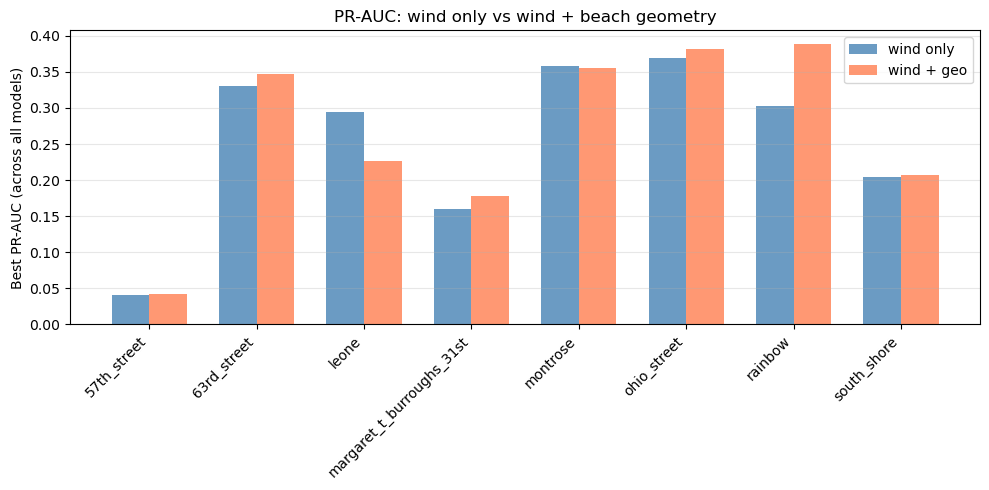

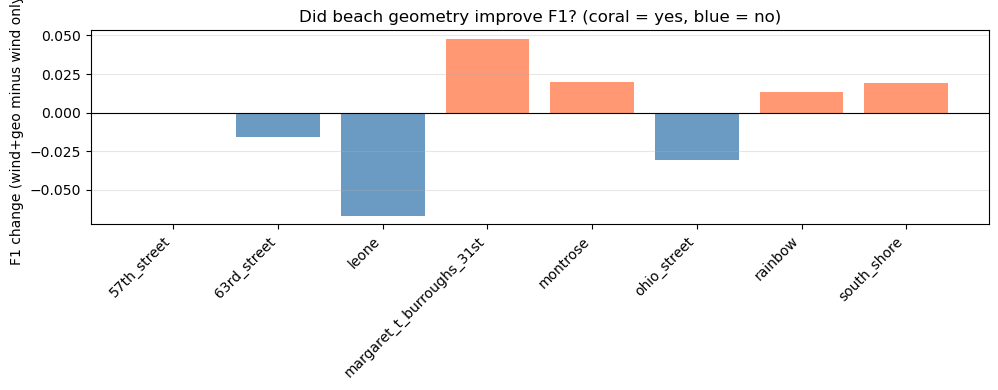

In [29]:
# ─── Comparison report: wind_only vs wind_geo ───────────────────────────
import matplotlib.pyplot as plt

# 1. Full results table at default threshold — all models including dummy
print("=== ALL RESULTS AT DEFAULT THRESHOLD ===\n")
report_cols = ["beach", "recipe_label", "model",
               "precision", "recall", "f1", "roc_auc", "pr_auc",
               "n_train_pos", "n_test_pos"]
print(
    master_results[report_cols]
    .sort_values(["beach", "recipe_label", "model"])
    .to_string(index=False)
)

# 2. Best model per beach × recipe at best threshold
print("\n\n=== BEST F1 AT ANY THRESHOLD (non-dummy) ===\n")
non_dummy = master_sweeps[master_sweeps["model"] != "dummy"]
best = (
    non_dummy
    .loc[non_dummy.groupby(["beach", "recipe_label", "model"])["f1"].idxmax()]
    .loc[lambda df: df.groupby(["beach", "recipe_label"])["f1"].transform("max") == df["f1"]]
    .sort_values(["beach", "recipe_label"])
    [["beach", "recipe_label", "model", "threshold", "precision", "recall", "f1", "tp", "fp", "fn"]]
)
print(best.to_string(index=False))

# 3. PR-AUC comparison plot: wind_only vs wind_geo, per beach
pivot = (
    master_results[master_results["model"] != "dummy"]
    .groupby(["beach", "recipe_label"])["pr_auc"].max()
    .unstack("recipe_label")
    .dropna(how="all")
)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(pivot))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], pivot.get("wind_only", 0),
               width, label="wind only", alpha=0.8, color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], pivot.get("wind_geo", 0),
               width, label="wind + geo", alpha=0.8, color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("Best PR-AUC (across all models)")
ax.set_title("PR-AUC: wind only vs wind + beach geometry")
ax.legend()
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# 4. F1 difference plot at best threshold
best_pivot = best.pivot_table(
    index="beach", columns="recipe_label", values="f1"
).dropna(how="all")

fig2, ax2 = plt.subplots(figsize=(10, 4))
if "wind_geo" in best_pivot.columns and "wind_only" in best_pivot.columns:
    diff = best_pivot["wind_geo"] - best_pivot["wind_only"]
    colors = ["coral" if d > 0 else "steelblue" for d in diff]
    ax2.bar(range(len(diff)), diff.values, color=colors, alpha=0.8)
    ax2.set_xticks(range(len(diff)))
    ax2.set_xticklabels(diff.index, rotation=45, ha="right")
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_ylabel("F1 change (wind+geo minus wind only)")
    ax2.set_title("Did beach geometry improve F1? (coral = yes, blue = no)")
    ax2.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("Need both recipe labels in results to compute difference plot.")

In [30]:
print(f"master_results: {len(master_results)} rows")
print(f"master_sweeps:  {len(master_sweeps)} rows")
print()

# Best model per beach at default threshold
summary = master_results.loc[
    master_results[master_results["model"] != "dummy"]
        .groupby("beach")["pr_auc"].idxmax()
][["beach", "model", "precision", "recall", "f1", "roc_auc", "pr_auc", "n_test_pos"]].sort_values("pr_auc", ascending=False)

print(summary.to_string(index=False))

master_results: 80 rows
master_sweeps:  448 rows

                    beach    model  precision   recall       f1  roc_auc   pr_auc  n_test_pos
                  rainbow logistic   0.181818 0.333333 0.235294 0.632302 0.388096           6
              ohio_street     lgbm   0.000000 0.000000 0.000000 0.709384 0.381166          17
                 montrose      hgb   0.000000 0.000000 0.000000 0.868357 0.358423           9
              63rd_street logistic   0.235294 0.666667 0.347826 0.724719 0.347216          12
                    leone     lgbm   1.000000 0.250000 0.400000 0.533163 0.294288           4
              south_shore logistic   0.117647 0.400000 0.181818 0.783505 0.207056           5
margaret_t_burroughs_31st     lgbm   0.000000 0.000000 0.000000 0.476648 0.178096           8
              57th_street     lgbm   0.000000 0.000000 0.000000 0.486395 0.042690           3


In [31]:
# Best f1 at any threshold, per beach × model
best_sweep = (
    master_sweeps
    .loc[master_sweeps.groupby(["beach", "model"])["f1"].idxmax()]
    [["beach", "model", "threshold", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]]
    .sort_values(["beach", "f1"], ascending=[True, False])
)

# Show top 2 models per beach
for beach in sorted(master_sweeps["beach"].unique()):
    sub = best_sweep[best_sweep["beach"] == beach].head(2)
    print(f"\n─── {beach} ───")
    print(sub.to_string(index=False))


─── 57th_street ───
      beach model  threshold  precision  recall  f1  tp  fp  fn  tn
57th_street   hgb        0.1        0.0     0.0 0.0   0   3   3  95
57th_street  lgbm        0.1        0.0     0.0 0.0   0   1   3  97

─── 63rd_street ───
      beach model  threshold  precision   recall       f1  tp  fp  fn  tn
63rd_street   hgb        0.2   0.400000 0.333333 0.363636   4   6   8  83
63rd_street  lgbm        0.1   0.363636 0.333333 0.347826   4   7   8  82

─── leone ───
beach model  threshold  precision  recall       f1  tp  fp  fn  tn
leone  lgbm       0.40        1.0    0.25 0.400000   1   0   3  98
leone   hgb       0.25        0.5    0.25 0.333333   1   1   3  97

─── margaret_t_burroughs_31st ───
                    beach model  threshold  precision  recall       f1  tp  fp  fn  tn
margaret_t_burroughs_31st  lgbm       0.20   0.500000    0.25 0.333333   2   2   6  89
margaret_t_burroughs_31st   xgb       0.15   0.333333    0.25 0.285714   2   4   6  87

─── montrose ───
  

In [32]:
# Best f1 across all thresholds, per (beach, recipe, model)
# best_per_combo = (
#     master_sweeps
#     .loc[master_sweeps.groupby(["beach", "recipe_label", "model"])["f1"].idxmax()]
#     .sort_values(["beach", "f1"], ascending=[True, False])
# )
# best_per_combo[["beach", "recipe_label", "model", "threshold", "precision", "recall", "f1", "tp", "fp", "fn"]]

# train test with CV

# Figures for report

In [33]:
# from precip_plots import plot_precip_coverage, plot_cumulative_precip, plot_precip_correlation, plot_rainy_hours
# from readings_plots import plot_readings_timeseries, plot_exceedance_rates

# # Precip
# fig1 = plot_precip_coverage(beach_coc_precip_df, usgs_precip_df)
# fig2 = plot_cumulative_precip(beach_coc_precip_df, usgs_precip_df)
# fig3 = plot_precip_correlation(beach_coc_precip_df, usgs_precip_df)
# fig4 = plot_rainy_hours(beach_coc_precip_df, usgs_precip_df)

# # Readings
# fig5 = plot_readings_timeseries(readings_df, MATTHEUS_BEACHES)
# fig6 = plot_exceedance_rates(readings_df, MATTHEUS_BEACHES)